In [1]:
import pandas as pd
import sys
import os

root_dir = os.path.dirname(os.path.dirname(os.getcwd()))
print(root_dir)
sys.path.insert(0, str(root_dir))

import _3DMorph.utils.analysis_utils as util

/home/ubuntu/3dmorph-clean/3dmorph


## First, collect all results into DataFrames

In [2]:
framework_filter = []

result_dict = util.load_results(frameworks_to_filter=framework_filter)

plot_dir = os.path.join(root_dir, "_3DMorph", "statistics_analysis", "plots")

n_bins = 50

percent_params = util.PlotParameters(
    density=False,
    tick_axis="both",
    n_bins=n_bins,
    median=True,
    number_mode="percent",
    precision=1,
    x_lim=(0.0, 1.0),
    save_dir=plot_dir,
    std=False
)

round_params = util.PlotParameters(
    density=False,
    tick_axis="both",
    n_bins=n_bins,
    median=True,
    number_mode="round",
    precision=3,
    save_dir=plot_dir,
    std=False
)

### Plot the distribution of Box/Img Ratios:

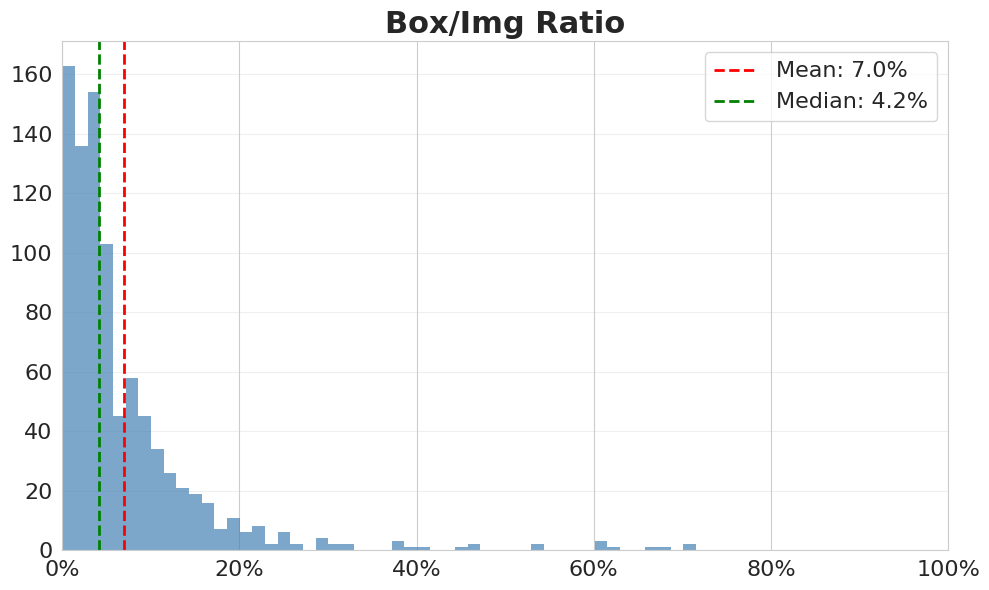

In [3]:
some_df = list(result_dict.values())[0]
a, b = util.plot_distribution({"Box/Img Ratio": some_df["box_img_ratio"]}, params=percent_params)

### Filter out samples where Box/Img Ratio is 0%, meaning that the augmentation can not be seen

In [6]:
filtered_result_dict = {}

for framework_name, framework_df in result_dict.items():
    # framework_df['view_angle'] = framework_df['view_angle'].str.split('_').str[0].astype(int)
    # framework_df = framework_df[framework_df["view_angle"] < -44]
    filtered_df = framework_df[framework_df["box_img_ratio"] > 0]
    print(f"For {framework_name} {len(framework_df) - len(filtered_df)} are filtered out. {len(filtered_df)} remain.")
    filtered_result_dict[framework_name] = filtered_df

For 3DMorph 20 are filtered out. 868 remain.
For Repaint 20 are filtered out. 868 remain.
For TRELLIS 20 are filtered out. 868 remain.
For Hunyuan3D 20 are filtered out. 868 remain.
For TripoSG 20 are filtered out. 868 remain.
For 3DMorph-BB 20 are filtered out. 868 remain.
For Repaint-BB 20 are filtered out. 868 remain.
For TRELLIS multi-view 0 are filtered out. 888 remain.


### Save the plots of all metrics and calculate mean & std

In [7]:
metric_column_names = [x for x in filtered_df.columns if x not in ["object_id", "view_angle", "box_img_ratio", "IoGT-BB"]]

means_data = []

for metric in metric_column_names:
    data_to_plot = {}
    for framework, framework_df in filtered_result_dict.items():
        values = framework_df[metric]
        means_data.append({
            "Metric": metric,
            "Framework": framework,
            "Mean": values.mean(),
            "Std": values.std(),
        })
        data_to_plot[framework] = values

    # Set up all plotting parameters
    params = percent_params.copy() if metric in ["IoU", "IoGT", "IoP", "Dice"] else round_params.copy()
    params.show = False
    if metric == "CD":
        params.x_lim = (0.0, 0.2)
    elif metric == "HD":
        params.x_lim = (0.0, 0.5)
    else:
        params.x_lim = (0.0, 1.0)
    params.n_bins = util.get_bin_array(params.x_lim, n_bins=params.n_bins)
    params.x_label = None
    params.y_lim = None
    os.makedirs(os.path.join(params.save_dir, metric), exist_ok=True)
    params.y_lim = util.plot_distribution(data_to_plot, params=params, save_name=f"{metric}/all.png")
    for framework, data in data_to_plot.items():
        util.plot_distribution(data, params=params, save_name=f"{metric}/{framework}.png")

full_df = pd.DataFrame(means_data)

other_cols = [col for col in full_df.columns if col not in ['Metric', 'Mean', "Std"]]
full_df_pivoted = full_df.pivot_table(index=other_cols, columns="Metric", values=["Mean", "Std"], aggfunc='first')
full_df_pivoted = full_df_pivoted.reset_index()

# Split means and stds into 2 dfs
means_only = full_df_pivoted[['Mean']].copy()
means_only.columns = means_only.columns.droplevel(0)
stds_only = full_df_pivoted[['Std']].copy()
stds_only.columns = stds_only.columns.droplevel(0)
means_only = pd.concat([full_df_pivoted[other_cols], means_only], axis=1)
stds_only = pd.concat([full_df_pivoted[other_cols], stds_only], axis=1)
means_only = means_only.rename(columns={means_only.columns[0]: 'Framework'})
stds_only = stds_only.rename(columns={stds_only.columns[0]: 'Framework'})

# Display all results
print("\n=== Means Summary ===")
print(means_only.to_string(index=False))
print("\n=== StDs Summary ===")
print(stds_only.to_string(index=False))


=== Means Summary ===
         Framework       CD     Dice     FSIM     GMSD       HD     IoGT      IoP      IoU  MS-SSIM     SSIM     ZNCC  max. CD
           3DMorph 0.010521 0.932623 0.806276 0.155689 0.028766 0.942204 0.926318 0.882164 0.876805 0.891563 0.943133 0.096905
        3DMorph-BB 0.008898 0.949526 0.835669 0.143553 0.024113 0.962745 0.938444 0.909681 0.909377 0.908910 0.966569 0.069902
         Hunyuan3D 0.026292 0.895807 0.751520 0.173908 0.074391 0.917290 0.880439 0.821848 0.843480 0.876167 0.934502 0.140509
           Repaint 0.012864 0.910488 0.795018 0.161680 0.036029 0.922845 0.903063 0.852437 0.860558 0.881155 0.927792 0.106677
        Repaint-BB 0.010190 0.933893 0.826941 0.147677 0.027669 0.948541 0.922987 0.886345 0.898973 0.903745 0.958363 0.077169
           TRELLIS 0.045791 0.840763 0.690182 0.206084 0.123257 0.913031 0.785358 0.740150 0.771176 0.834748 0.888412 0.207571
TRELLIS multi-view 0.034187 0.869203 0.696327 0.202297 0.096242 0.937032 0.814458 0.7790

### Plot the means and stds for selected metrics:

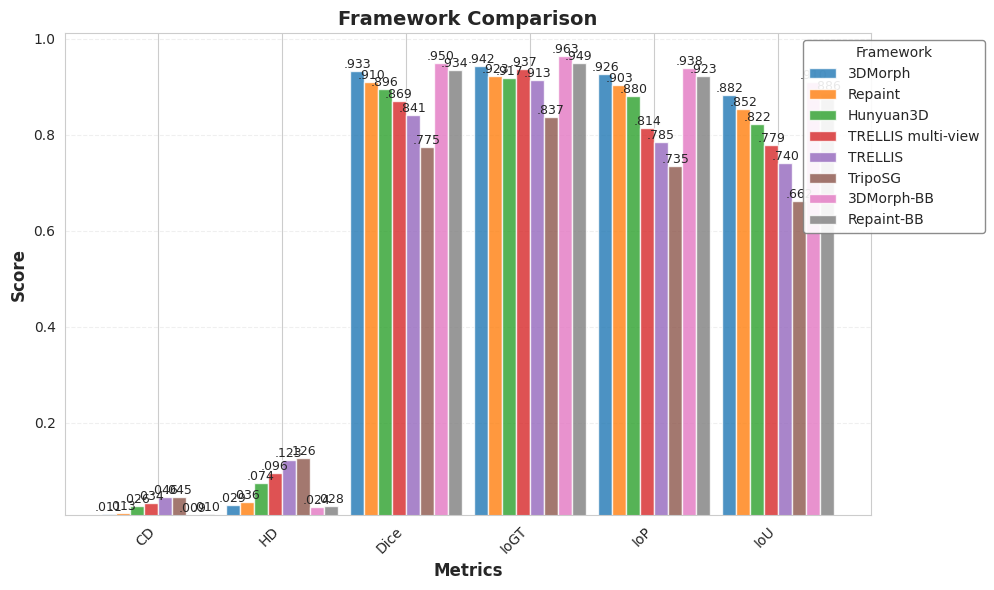

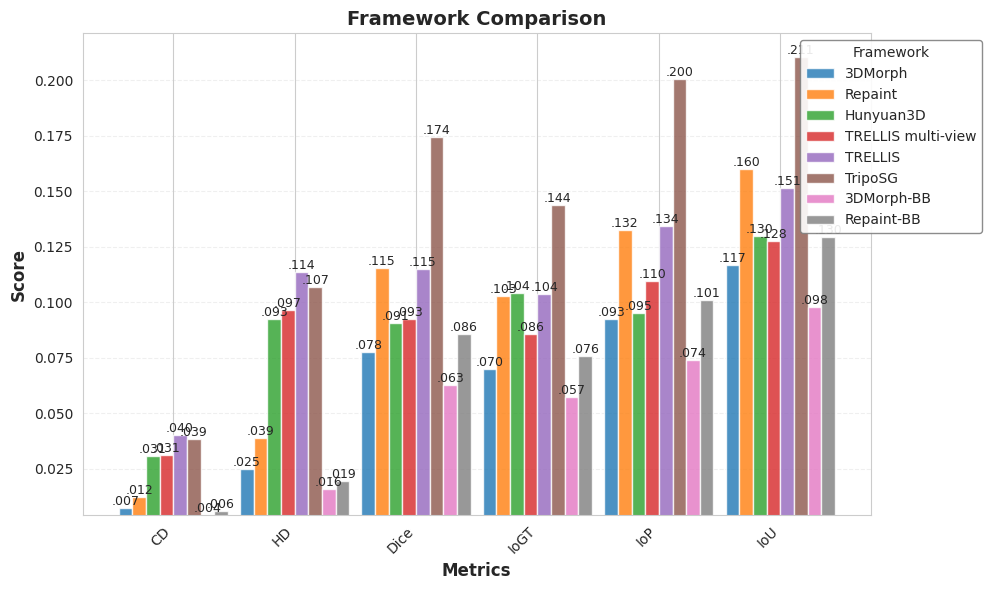

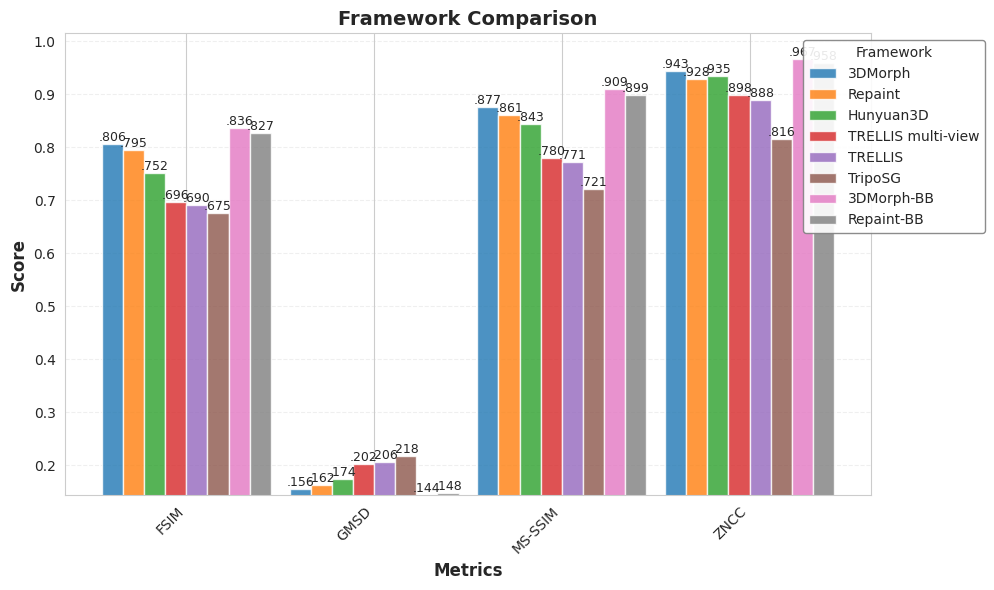

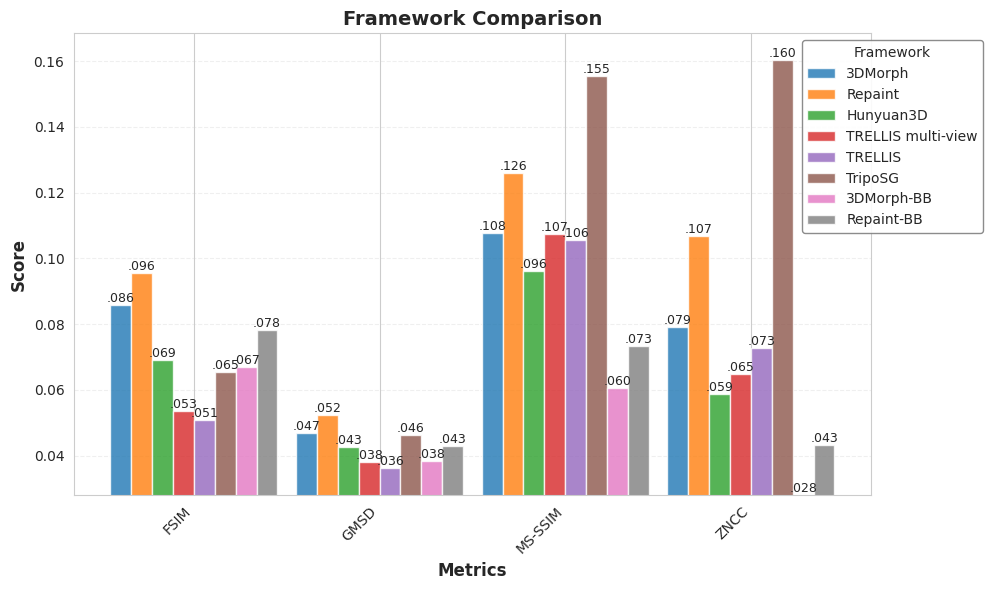

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Framework Comparison'}, xlabel='Metrics', ylabel='Score'>)

In [8]:
params = util.PlotParameters(
    tick_axis="both",
    number_mode="round",
    precision=3,
    figsize=(20, 8)
)

geometric_metrics_to_plot = ["CD", "HD", "Dice", "IoGT", "IoP", "IoU"]
image_metrics_to_plot = ["FSIM", "GMSD", "MS-SSIM", "ZNCC"]
order = ["3DMorph", "Repaint", "Hunyuan3D", "TRELLIS multi-view", "TRELLIS", "TripoSG", "3DMorph-BB", "Repaint-BB"]

params.title = "Means for Geometric Metrics"
util.plot_framework_comparison(means_only[["Framework"] + geometric_metrics_to_plot], custom_order=order)
params.title = "Standard Deviations for Geometric Metrics"
util.plot_framework_comparison(stds_only[["Framework"] + geometric_metrics_to_plot], custom_order=order)

params.title = "Means for Image Metrics"
util.plot_framework_comparison(means_only[["Framework"] + image_metrics_to_plot], custom_order=order)
params.title = "Standard Deviations for Image Metrics"
util.plot_framework_comparison(stds_only[["Framework"] + image_metrics_to_plot], custom_order=order)